# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [4]:
import pandas as pd

df = pd.read_csv('/Users/dana/Desktop/data analytics/data/House_Rent_Dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [5]:
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [8]:
missing_data = df.isnull().sum()
missing_percent = (missing_data/len(df)) * 100

missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

In [10]:
stats = df[['BHK', 'Rent', 'Size', 'Bathroom']].describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


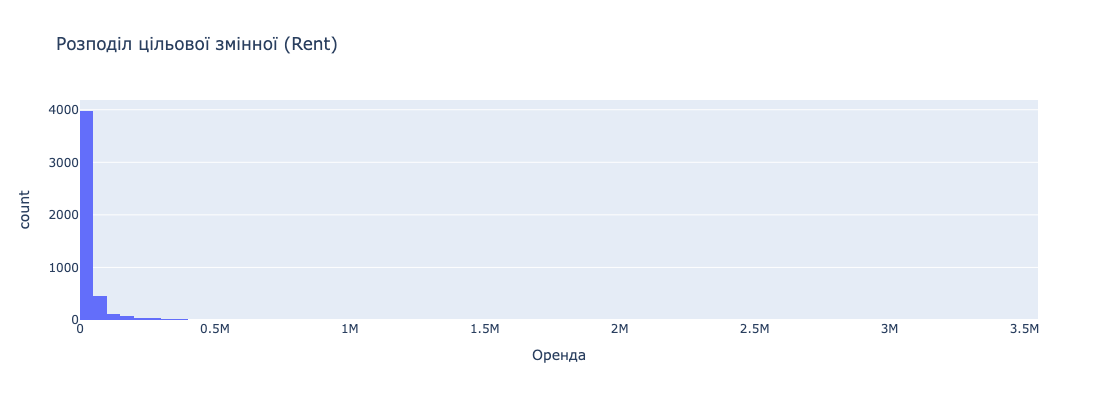

In [12]:
import plotly.express as px

fig = px.histogram(
    df,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (Rent)',
    labels={'Rent': 'Оренда', 'count': 'Кількість оголошень'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

In [13]:
# квартилі та IQR для цільової змінної Rent
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Нижня межа:", lower_bound)
print("Верхня межа:", upper_bound)

Q1: 10000.0
Q3: 33000.0
IQR: 23000.0
Нижня межа: -24500.0
Верхня межа: 67500.0


In [14]:
outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]

print("Кількість викидів у Rent:", outliers.shape[0])
outliers[['Rent']].head()

Кількість викидів у Rent: 520


,Rent
104,180000
525,70000
527,75000
530,160000
531,300000


In [16]:
df_no_outliers = df[ (df['Rent'] >= lower_bound) & (df ['Rent'] <= upper_bound)]. copy()

print("Розмір датасету до видалення викидів:", df.shape)
print("Розмір датасету після видалення викидів:", df_no_outliers.shape)

Розмір датасету до видалення викидів: (4746, 12)
Розмір датасету після видалення викидів: (4226, 12)


In [17]:
categorical_cols = df.select_dtypes(include='object').columns

unique_counts = pd.DataFrame({
    'Column': categorical_cols,
    'Unique Values': [df[col].nunique() for col in categorical_cols]
})

unique_counts

,Column,Unique Values
0,Posted On,81
1,Floor,480
2,Area Type,3
3,Area Locality,2235
4,City,6
5,Furnishing Status,3
6,Tenant Preferred,3
7,Point of Contact,3



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [19]:
correlation_matrix = df_no_outliers.select_dtypes('number').corr()
correlation_matrix

,BHK,Rent,Size,Bathroom
BHK,1.000000,0.401268,0.698453,0.747918
Rent,0.401268,1.000000,0.393605,0.506528
Size,0.698453,0.393605,1.000000,0.680607
Bathroom,0.747918,0.506528,0.680607,1.000000


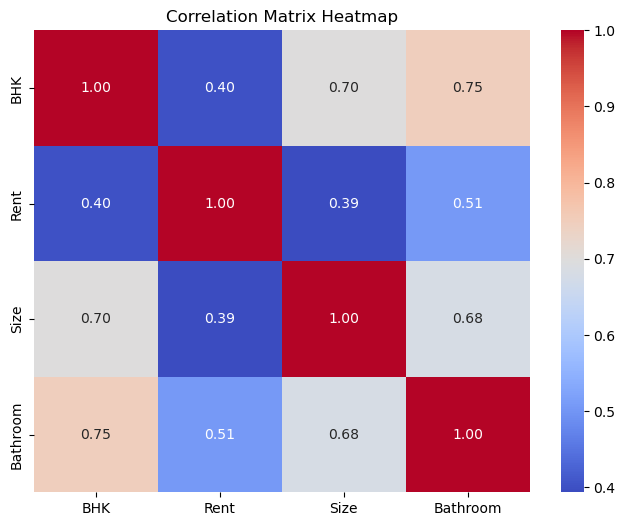

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df_no_outliers.select_dtypes('number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

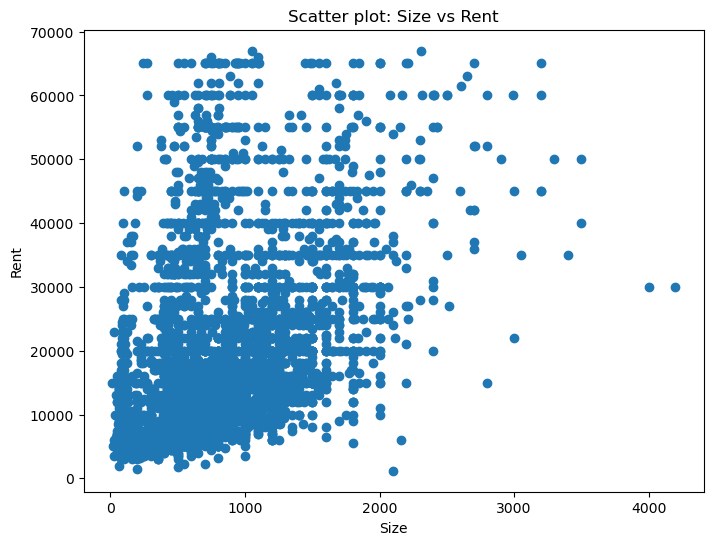

In [21]:
plt.figure(figsize = (8,6))
plt.scatter(df_no_outliers['Size'], df_no_outliers['Rent'])
plt.xlabel('Size')
plt.ylabel('Rent')
plt.title('Scatter plot: Size vs Rent')
plt.show()

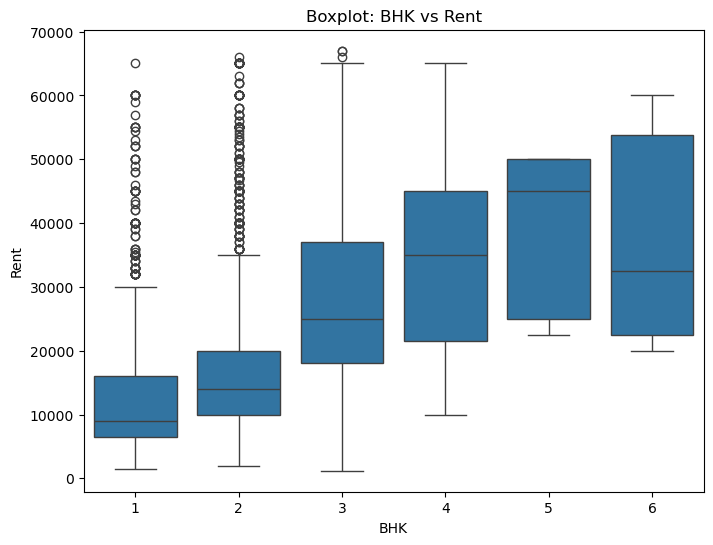

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='BHK', y='Rent', data=df_no_outliers)
plt.title('Boxplot: BHK vs Rent')
plt.xlabel('BHK')
plt.ylabel('Rent')
plt.show()

Розкид цін стає більшим при вищих значеннях BHK, а це оначає,що  серед великих квартир ціни більш різноманітні.

Є ще викиди, особливо для 1–3 BHK, тобто навіть серед менших квартир трапляються дуже дорогі варіанти.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [23]:
import pandas as pd
import numpy as np

df['Floor_current'] = df['Floor'].str.split(' out of ').str[0]
df['Floor_total'] = pd.to_numeric(df['Floor'].str.split(' out of ').str[1], errors='coerce')

df['Floor_current'] = df['Floor_current'].replace({
    'Ground': 0,
    'Upper Basement': -1,
    'Lower Basement': -2
})

df['Floor_current'] = pd.to_numeric(df['Floor_current'], errors='coerce')

df[['Floor', 'Floor_current', 'Floor_total']].head(15)

,Floor,Floor_current,Floor_total
0,Ground out of 2,0,2.0
1,1 out of 3,1,3.0
2,1 out of 3,1,3.0
3,1 out of 2,1,2.0
4,1 out of 2,1,2.0
5,Ground out of 1,0,1.0
6,Ground out of 4,0,4.0
7,1 out of 2,1,2.0
8,1 out of 2,1,2.0
9,1 out of 3,1,3.0


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df_model = df_no_outliers.copy()

df_model['Rooms_per_Bathroom'] = df_model['BHK'] / df_model['Bathroom']
df_model = df_model.replace([np.inf, -np.inf], np.nan)

cat_cols = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

drop_cols = ['Rent', 'Floor', 'Area Locality', 'Posted On']
X = df_model.drop(columns=drop_cols)
y = df_model['Rent']

X = X.fillna(X.median(numeric_only=True))

num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (4226, 17)
y shape: (4226,)


,BHK,Size,Bathroom,Rooms_per_Bathroom,Area Type_Carpet Area,Area Type_Super Area,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,0.052966,0.469859,0.272578,-0.358513,False,True,False,False,False,True,False,False,True,True,False,False,True
1,0.052966,-0.147778,-1.133910,2.242635,False,True,False,False,False,True,False,True,False,True,False,False,True
2,0.052966,0.263980,-1.133910,2.242635,False,True,False,False,False,True,False,True,False,True,False,False,True
3,0.052966,-0.147778,-1.133910,2.242635,False,True,False,False,False,True,False,False,True,True,False,False,True
4,0.052966,-0.044839,-1.133910,2.242635,True,False,False,False,False,True,False,False,True,False,False,False,True


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [25]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3380, 17)
X_test: (846, 17)
y_train: (3380,)
y_test: (846,)


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [27]:
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")и

BHK: 3894.88
Size: 3865.96
Bathroom: 549.46
Rooms_per_Bathroom: -994.18
Area Type_Carpet Area: -2235.77
Area Type_Super Area: -2481.75
City_Chennai: -1185.80
City_Delhi: 1969.39
City_Hyderabad: -2394.47
City_Kolkata: -3085.37
City_Mumbai: 18580.95
Furnishing Status_Semi-Furnished: -3414.13
Furnishing Status_Unfurnished: -4538.04
Tenant Preferred_Bachelors/Family: -648.50
Tenant Preferred_Family: -2248.90
Point of Contact_Contact Builder: -5963.72
Point of Contact_Contact Owner: -8741.39

Зміщення (intercept): 30562.17


Найбільший вплив на прогноз мають ознаки City_Mumbai та Point of Contact_Contact Owner, вони мають найбільші за модулем коефіцієнти.

In [32]:
# Прогнози на навчальній вибірці
y_train_pred = model.predict(X_train)

# Прогнози на тестовій вибірці
y_test_pred = model.predict(X_test)

# Порівняння перших 10 прогнозів з реальними значеннями
comparison = pd.DataFrame({
    'Реальна оренда': y_test.values[:10],
    'Прогнозована оренда': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})

print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна оренда  Прогнозована оренда  Помилка
0           22000              28577.0  -6577.0
1            5000               3533.0   1467.0
2           37000              40327.0  -3327.0
3            8000               3120.0   4880.0
4           15000              15411.0   -411.0
5           20000              24498.0  -4498.0
6            8500              17916.0  -9416.0
7            7000               4349.0   2651.0
8            3000                440.0   2560.0
9            8000               5224.0   2776.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Розраховуємо метрики для тестової вибірки
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")
print(f"R²: {r2:.3f}")

# Порівняння з навчальною вибіркою
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 5509.64 
RMSE: 7725.73 
R²: 0.689
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 5525.46 
RMSE: 7690.08 
R²: 0.690


Метрики на тренувальній та тестовій вибірках майже однакові. Значення R² близько 0.69 показує, що модель пояснює приблизно 69% варіації цільової змінної. Ознак перенавчання нема. Також немає ознак недонавчання, тому модель можна вважати достатньо якісною.

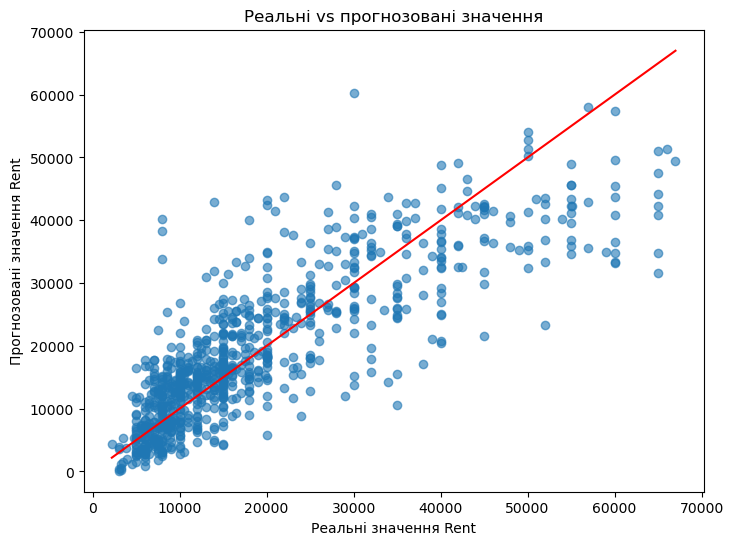

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.xlabel("Реальні значення Rent")
plt.ylabel("Прогнозовані значення Rent")
plt.title("Реальні vs прогнозовані значення")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

Більшість точок лежить близько до діагоналі, тому модель прогнозує досить добре. Але розкид навколо лінії показує, що є помилки, особливо для великих значень оренди.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

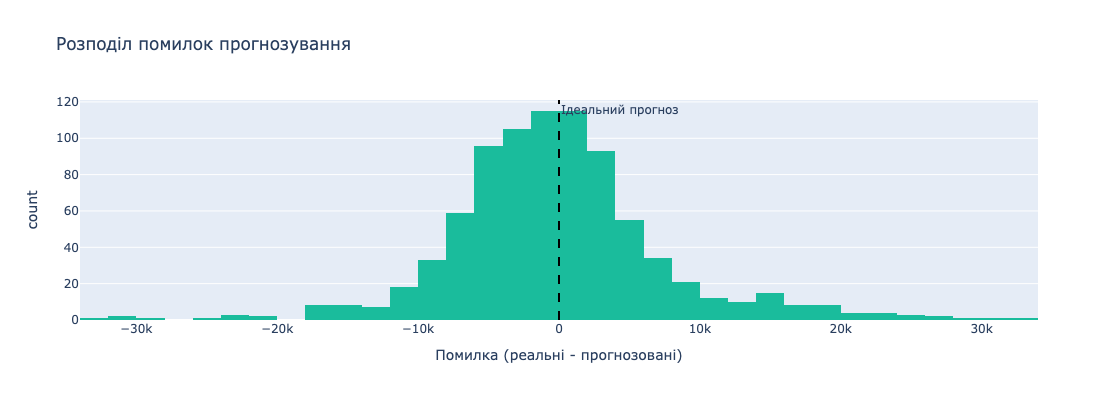

In [36]:
residuals = y_test - y_test_pred

fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#1abc9c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

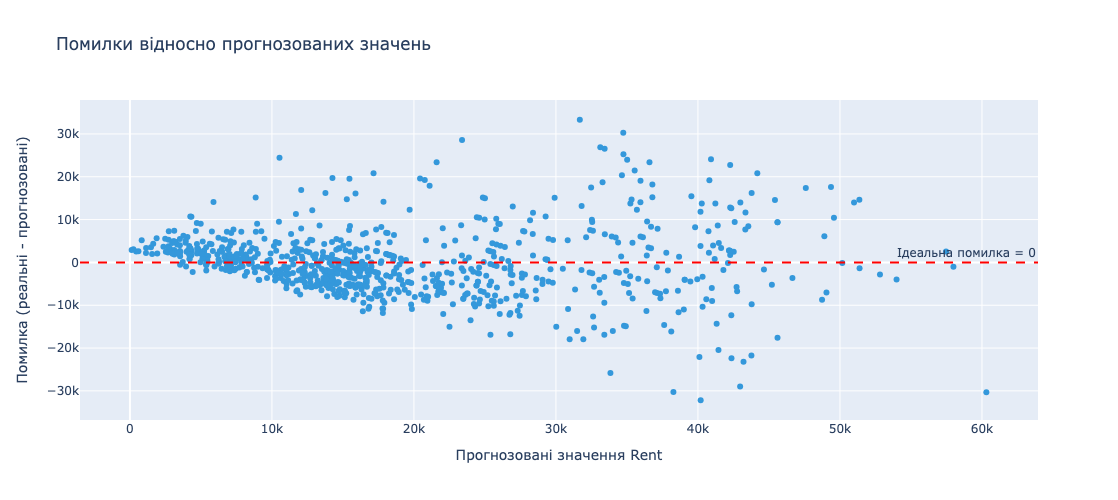

In [37]:
import plotly.express as px

residuals = y_test - y_test_pred

fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Помилки відносно прогнозованих значень',
    labels={'x': 'Прогнозовані значення Rent', 'y': 'Помилка (реальні - прогнозовані)'},
    color_discrete_sequence=['#3498db']
)

fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Ідеальна помилка = 0")
fig.update_layout(height=500)
fig.show()

помилка моделі росте для більших значень орендної плати, а це означає, що модель прогнозує дорогі об’єкти менш точно, ніж дешевші.

In [38]:
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(y_test.values - y_test_pred)
})

top_errors = errors_df.nlargest(5, 'error')
print("5 прогнозів з найбільшими помилками:")
print(top_errors)

5 прогнозів з найбільшими помилками:
      real     predicted         error
642  65000  31682.073300  33317.926700
193   8000  40191.627096  32191.627096
122  30000  60308.763818  30308.763818
210   8000  38271.796094  30271.796094
337  65000  34740.600735  30259.399265


In [41]:
analysis_df = pd.DataFrame({
    'BHK': df_no_outliers.loc[X_test.index, 'BHK'],
    'real_rent': y_test.values,
    'predicted_rent': y_test_pred,
    'abs_error': np.abs(y_test.values - y_test_pred)
})

print("Середня абсолютна помилка за BHK:")
display(analysis_df.groupby('BHK')['abs_error'].mean().sort_values(ascending=False))

Середня абсолютна помилка за BHK:


BHK
4    12150.256253
3     7884.989779
6     6475.736721
2     5011.017482
1     4398.915077
5     2818.407550
Name: abs_error, dtype: float64

In [40]:
analysis_df = X_test.copy()
analysis_df['real_rent'] = y_test.values
analysis_df['predicted_rent'] = y_test_pred
analysis_df['abs_error'] = np.abs(y_test.values - y_test_pred)

city_cols = [col for col in analysis_df.columns if col.startswith('City_')]
analysis_df['City_decoded'] = 'base_city'

for col in city_cols:
    analysis_df.loc[analysis_df[col] == 1, 'City_decoded'] = col.replace('City_', '')

print("Середня абсолютна помилка за містом:")
display(analysis_df.groupby('City_decoded')['abs_error'].mean().sort_values(ascending=False))

Середня абсолютна помилка за містом:


City_decoded
Mumbai       9138.671254
Delhi        7284.392076
Hyderabad    5047.188827
Chennai      4708.066635
Kolkata      4187.208643
base_city    3968.535710
Name: abs_error, dtype: float64

Модель найбільше помиляється на 4-кімнатних квартирах, а також на житлі в Mumbai та Delhi. Це свідчить про те, що для більш складних або дорожчих сегментів ринку проста лінійна модель працює гірше.

 Щоб покращити модель, можна спробувати логарифмувати "Rent", це може зменшити помилки на дорогих квартирах. Спробувати нелінійні моделі. Окремо перевірити кількість об’єктів у групах, можливо, для 4-кімнатних або 6-кімнатних квартир просто менше даних, тому модель там слабша